# Hopfield and memory demos and explorations

## Section 1:

Vanilla hopfield

In [3]:
import torch.nn as nn
import torch 
import numpy as np
from matplotlib import pyplot as plt

In [54]:
class HopfieldNet(nn.Module):
    def __init__(self, num_units):
        super(HopfieldNet, self).__init__()
        self.num_units = num_units
        self.weights = nn.Parameter(torch.zeros(num_units, num_units), requires_grad=False)

    def store(self, states):
        """
        Store a set of states in the network.
        :param states: A tensor of shape (num_states, num_units)
        """
        num_states = states.size(0)
        for state in states:
            self.weights.data += torch.outer(state, state)
        self.weights.data /= num_states

class VanillaHopfieldNet(HopfieldNet):
    def __init__(self, num_units):
        super(VanillaHopfieldNet, self).__init__(num_units)

    def forward(self, state, num_iterations=10):
        """
        Update the state of the network.
        :param state: A tensor of shape (num_units,)
        :param num_iterations: Number of iterations to run the update
        :return: The updated state
        """
        for _ in range(num_iterations):
            state = torch.sign(torch.matmul(self.weights, state))
        return state

    def store(self, states):
        """
        Store a set of states in the network.
        :param states: A tensor of shape (num_states, num_units)
        """
        
        num_states = states.size(0)
        for state in states:
            self.weights.data += 4 * torch.outer(2 * state - 1, 2 * state - 1)
        self.states = states
        

# Example usage
num_units = 10
states = torch.randint(0, 2, (5, num_units)).float()

hopfield_net = VanillaHopfieldNet(num_units)
hopfield_net.store(states)

initial_state = torch.randint(0, 2, (num_units,)).float() 

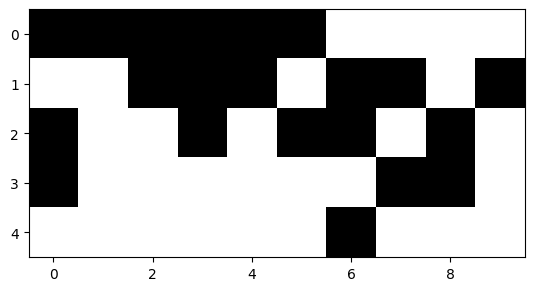

In [55]:
plt.imshow(hopfield_net.states.cpu().numpy(), cmap='gray')

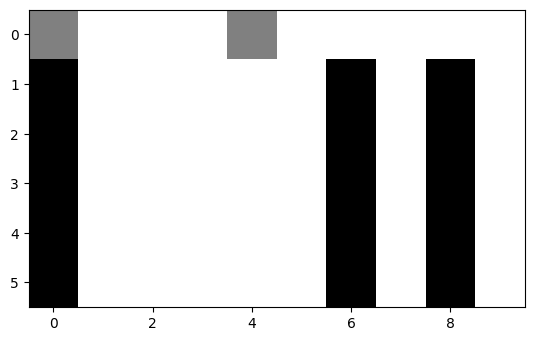

In [57]:
initial_state = torch.randint(0, 2, (num_units,)).float()
initial_state = 1- torch.tensor([1, 0, 0, 0, 1, 0, 0, 0, 0, 0]).float()
state2s=[initial_state]
updates = 5
for i in range(updates): 
    state2s.append(hopfield_net(state2s[-1]))

plt.imshow(torch.cat([state2.unsqueeze(1) for state2 in state2s], dim=-1).cpu().numpy().T, cmap='gray')

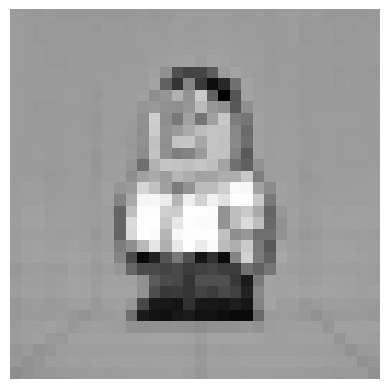

In [58]:
from PIL import Image

# Load the generated image
image_path = "image_sample2.webp"
image = Image.open(image_path)

# Resize to 32x32 for Hopfield network demonstration
image_resized = image.resize((32, 32)).convert("L")  # Convert to grayscale

# Convert to tensor format (numpy array)
image_tensor = np.array(image_resized) / 255.0  # Normalize values between 0 and 1

# Display the resized image
plt.imshow(image_tensor, cmap="gray")
plt.axis("off")
plt.show()

In [69]:
num_units = 32 * 32
states = torch.randint(0, 2, (10, num_units)).float()
states[0] = torch.tensor(image_tensor.flatten()>0.7).float()
hopfield_net = VanillaHopfieldNet(num_units)
hopfield_net.store(states)

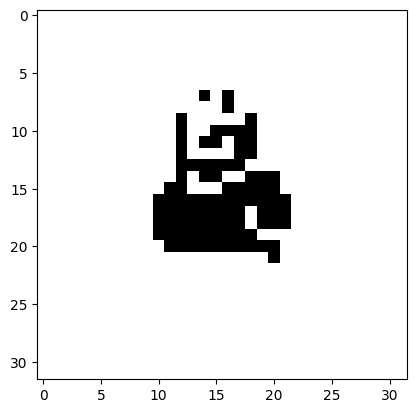

In [74]:
masked_state = torch.tensor(image_tensor.flatten()>0.15).float()
retrieved_state = hopfield_net(masked_state)
plt.imshow(retrieved_state.view(32, 32).cpu().numpy(), cmap='gray')